In [1]:
import tensorflow as tf
from tensorflow import keras

In [3]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.metrics


from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from tensorflow.keras.applications import EfficientNetB0  # or B1, B2...B7 for different versions
from tensorflow.keras.layers import Dense, Flatten, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

tf.config.list_physical_devices('GPU')

[]

In [6]:
data_dir = r"D:\ML\Dataset - train+val+test"
data = tf.keras.preprocessing.image_dataset_from_directory(data_dir)

Found 109309 files belonging to 3 classes.


In [7]:
base_dir = os.path.join(r"D:\ML\Dataset - train+val+test")
print('Base directory --> ', os.listdir(base_dir))

Base directory -->  ['test', 'train', 'val']


In [8]:
train_dir = os.path.join(base_dir + "/train")
print("Train Directory --> ", os.listdir(train_dir))

validation_dir = os.path.join(base_dir + "/val")
print("Validation Directory --> ", os.listdir(validation_dir))

test_dir = os.path.join(base_dir + "/test")
print("Test Directory --> ", os.listdir(test_dir))

Train Directory -->  ['CNV', 'DME', 'DRUSEN', 'NORMAL']
Validation Directory -->  ['CNV', 'DME', 'DRUSEN', 'NORMAL']
Test Directory -->  ['CNV', 'DME', 'DRUSEN', 'NORMAL']


In [9]:
cnv = len(os.listdir(os.path.join(train_dir + "/CNV")))
dme = len(os.listdir(os.path.join(train_dir + "/DME")))
drusen = len(os.listdir(os.path.join(train_dir + "/DRUSEN")))
normal = len(os.listdir(os.path.join(train_dir + "/NORMAL")))

counts = [cnv, dme, drusen, normal]

In [10]:
#Not Exhanged

train_dir = r"D:\ML\Dataset - train+val+test\train"
print("Train Directory --> ", os.listdir(train_dir))

validation_dir = r"D:\ML\Dataset - train+val+test\val"
print("Validation Directory --> ", os.listdir(validation_dir))

test_dir = r"D:\ML\Dataset - train+val+test\test"
print("Test Directory --> ", os.listdir(test_dir))

Train Directory -->  ['CNV', 'DME', 'DRUSEN', 'NORMAL']
Validation Directory -->  ['CNV', 'DME', 'DRUSEN', 'NORMAL']
Test Directory -->  ['CNV', 'DME', 'DRUSEN', 'NORMAL']


In [11]:
cnv = len(os.listdir(os.path.join(train_dir + "/CNV")))
dme = len(os.listdir(os.path.join(train_dir + "/DME")))
drusen = len(os.listdir(os.path.join(train_dir + "/DRUSEN")))
normal = len(os.listdir(os.path.join(train_dir + "/NORMAL")))

counts = [cnv, dme, drusen, normal]

In [12]:
from sklearn.utils import class_weight
import numpy as np

class_counts = np.array(counts)
class_labels = np.array([0, 1, 2, 3])  # [CNV -> 0, DME -> 1, DRUSEN -> 2, NORMAL -> 3]

# Calculate class weights
weights = class_weight.compute_class_weight(class_weight='balanced', 
                                            classes=class_labels, 
                                            y=np.repeat(class_labels, class_counts))
class_weights = dict(enumerate(weights))

print("Class Weights:", class_weights)

Class Weights: {0: np.float64(0.7296037073766115), 1: np.float64(2.356337767923134), 2: np.float64(3.082299387689333), 3: np.float64(0.5317529814027188)}


In [13]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

batch_size = 32  # safer and more efficient

train_datagen = ImageDataGenerator(
    rescale=1./255,
    zoom_range=0.2,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='categorical'
)

validation_generator = val_datagen.flow_from_directory(
    validation_dir,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='categorical'
)


Found 76515 images belonging to 4 classes.
Found 21861 images belonging to 4 classes.


##### DATA AUGMENTATION

In [14]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Set batch size
batch_size = 32

# Training data with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    zoom_range=0.2,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True
)

# Validation data (no augmentation)
val_datagen = ImageDataGenerator(rescale=1./255)

# Test data (optional, no augmentation)
test_datagen = ImageDataGenerator(rescale=1./255)

# Load training data
train_generator = train_datagen.flow_from_directory(
    r"D:\ML\Dataset - train+val+test\train",         # Replace with your actual path
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='categorical'
)

# Load validation data
validation_generator = val_datagen.flow_from_directory(
    r"D:\ML\Dataset - train+val+test\val",    # Replace with your actual path
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='categorical'
)

# Load test data (optional)
test_generator = test_datagen.flow_from_directory(
    r"D:\ML\Dataset - train+val+test\test",          # Replace with your actual path
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False                   # Important for evaluation/prediction
)


Found 76515 images belonging to 4 classes.
Found 21861 images belonging to 4 classes.
Found 10933 images belonging to 4 classes.


##### DEFINE MODEL

In [15]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = True
for layer in base_model.layers[:100]:  # Freeze first 100 layers
    layer.trainable = False


In [16]:
from keras.layers import GlobalAveragePooling2D
from keras import models
from keras import layers


model = models.Sequential()
model.add(base_model)
model.add(GlobalAveragePooling2D())  # Better than Flatten
model.add(layers.Dense(4, activation='softmax'))


In [25]:
from tensorflow.keras.metrics import AUC, Precision, Recall  # ✅ add this line
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.optimizers import Adam

model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy', AUC(), Precision(), Recall()])



In [26]:
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
lr_schedule = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)


In [27]:
# train_datagen = ImageDataGenerator(rescale = 1./255)
# train_generator = train_datagen.flow_from_directory(
#     train_dir, target_size = (224,224), class_mode = 'categorical', 
#     batch_size = 500)

In [28]:
# test_datagen = ImageDataGenerator(rescale = 1./255)
# test_generator = test_datagen.flow_from_directory(
#     test_dir, target_size = (224,224), class_mode = 'categorical', shuffle=False, 
#     batch_size = 50)

In [29]:
# validation_datagen = ImageDataGenerator(rescale = 1./255)
# validation_generator = validation_datagen.flow_from_directory(
#     validation_dir, target_size = (224,224), class_mode = 'categorical', 
#     batch_size = 16)

In [30]:
# from tensorflow.keras.callbacks import EarlyStopping

# early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
# # model.fit(train_generator, epochs=30, validation_data=validation_generator, )

In [31]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Callbacks to improve training
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_schedule = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)

# Train the model
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    callbacks=[early_stop, lr_schedule]
)


C:\Users\VI3CATH ADMIN\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
2392/2392 ━━━━━━━━━━━━━━━━━━━━ 790s 329ms/step - accuracy: 0.8796 - auc_1: 0.9783 - loss: 0.3456 - precision_1: 0.9080 - recall_1: 0.8517 - val_accuracy: 0.9245 - val_auc_1: 0.9900 - val_loss: 0.2213 - val_precision_1: 0.9313 - val_recall_1: 0.9169 - learning_rate: 1.0000e-05
Epoch 2/10
2392/2392 ━━━━━━━━━━━━━━━━━━━━ 787s 329ms/step - accuracy: 0.9271 - auc_1: 0.9904 - loss: 0.2135 - precision_1: 0.9337 - recall_1: 0.9209 - val_accuracy: 0.9361 - val_auc_1: 0.9922 - val_loss: 0.1899 - val_precision_1: 0.9404 - val_recall_1: 0.9313 - learning_rate: 1.0000e-05
Epoch 3/10
2392/2392 ━━━━━━━━━━━━━━━━━━━━ 752s 314ms/step - accuracy: 0.9388 - auc_1: 0.9928 - loss: 0.1799 - precision_1: 0.9432 - recall_1: 0.9347 - val_accuracy: 0.9411 - val_auc_1: 0.9933 - val_loss: 0.1724 - val_precision_1: 0.9445 - val_recall_1: 0.9380 - learning_rate: 1.0000e-05
Epoch 4/10
2392/2392 ━━━━━━━━━━━━━━━━━━━━ 776s 324ms/step - accuracy: 0.9467 - auc_1: 0.9943 - loss: 0.1585 - precision_1: 0.9502 - reca

In [39]:
# history = model.fit(
#     train_generator,
#     steps_per_epoch = (76515 // 500),
#     epochs = 15,
#     validation_data = validation_generator,
#     validation_steps = (10933 // 16),
#     callbacks=[early_stop]
# )


In [32]:
model.save('MobileNet_Class_Weights_trial_3.keras')

In [33]:
import pickle

metrics of MobileNet


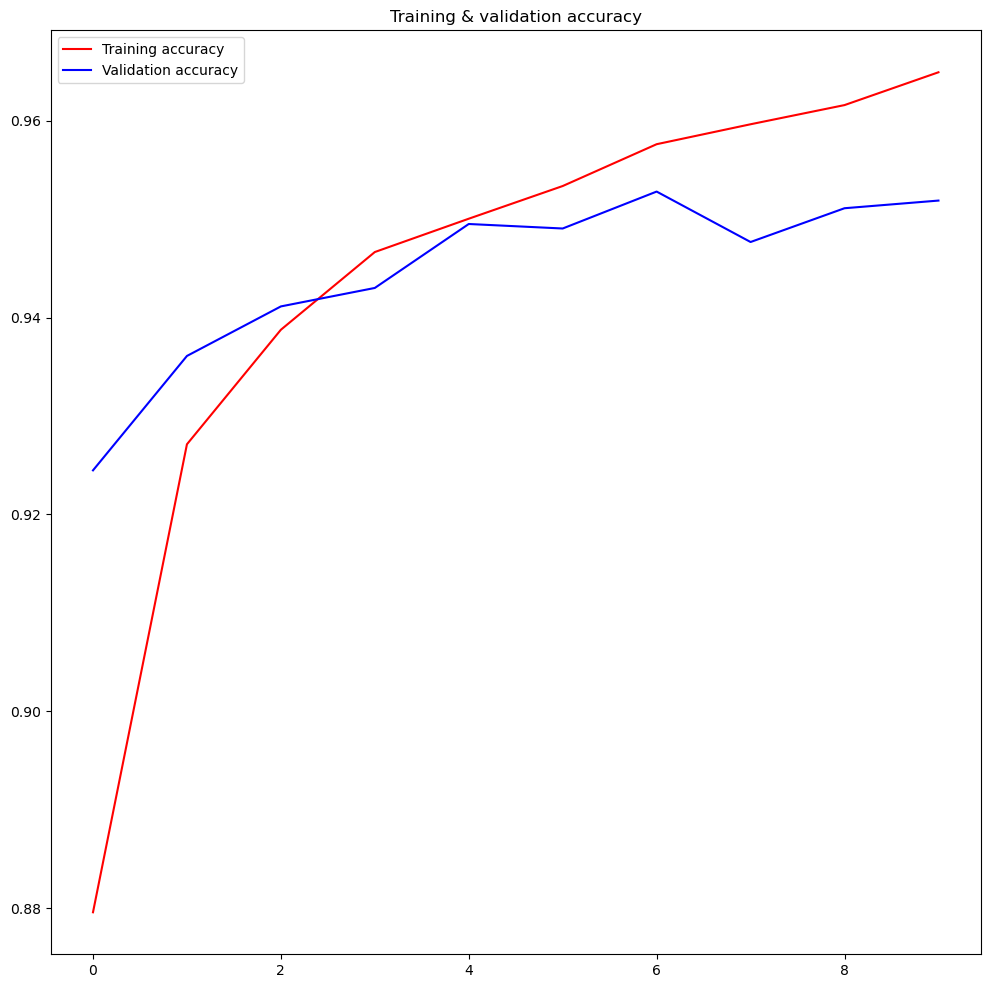

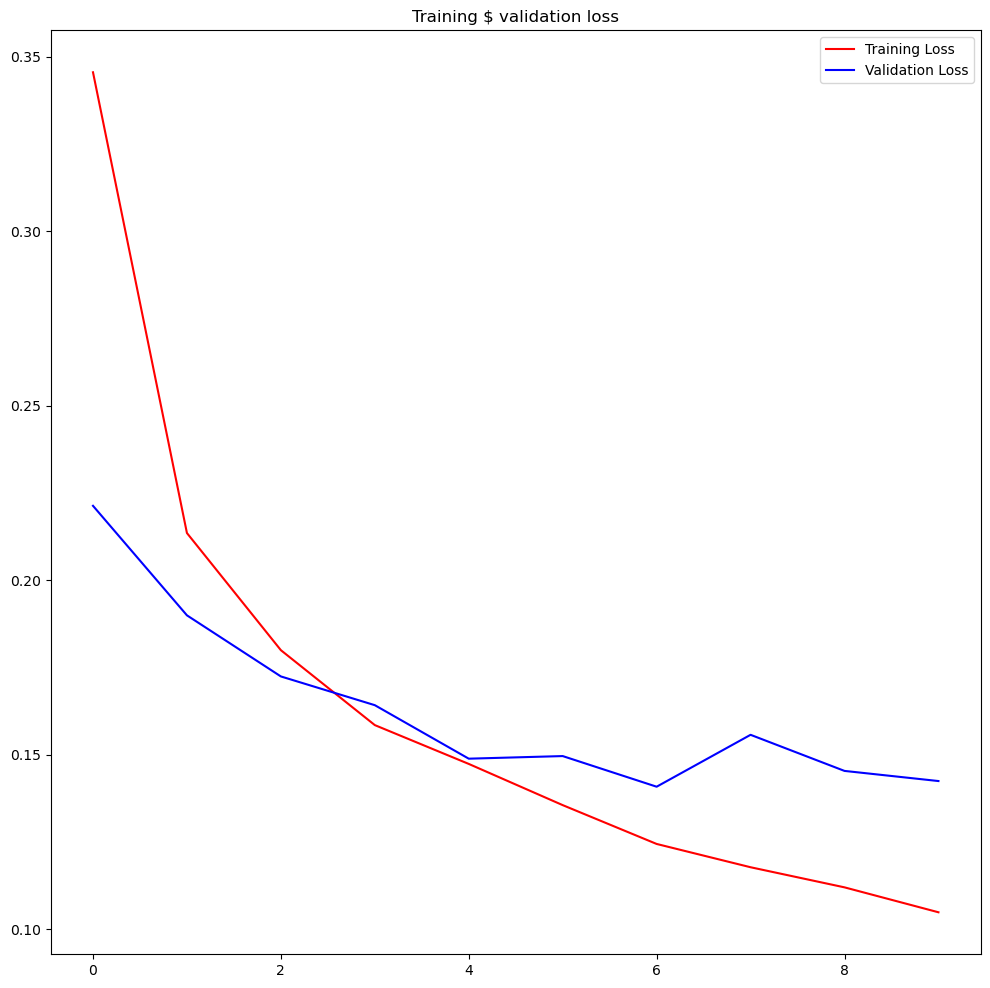

In [34]:
print("metrics of MobileNet")
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.figure(figsize=(12,12))

plt.plot(epochs, acc, 'r', label = 'Training accuracy')
plt.plot(epochs, val_acc, 'b', label = 'Validation accuracy')
plt.title('Training & validation accuracy')
plt.legend()

plt.figure(figsize = (12,12))

plt.plot(epochs, loss, 'r', label = 'Training Loss')
plt.plot(epochs, val_loss, 'b', label = 'Validation Loss')
plt.title('Training $ validation loss')
plt.legend()

plt.show()

In [35]:
test_datagen = ImageDataGenerator(rescale = 1./255)
test_generator = test_datagen.flow_from_directory(
    test_dir, target_size = (224,224), class_mode = 'categorical', shuffle=False, 
    batch_size = 64)

Found 10933 images belonging to 4 classes.


In [36]:
model.evaluate(test_generator)

171/171 ━━━━━━━━━━━━━━━━━━━━ 40s 235ms/step - accuracy: 0.9500 - auc_1: 0.9950 - loss: 0.1459 - precision_1: 0.9526 - recall_1: 0.9477


[0.14588938653469086,
 0.9499679803848267,
 0.9949693083763123,
 0.9526480436325073,
 0.9476813077926636]

In [37]:
import math 

test_steps_per_epoch = math.ceil(test_generator.samples / test_generator.batch_size)

predictions = model.predict(test_generator, steps=test_steps_per_epoch)

predicted_classes = np.argmax(predictions, axis=1)


171/171 ━━━━━━━━━━━━━━━━━━━━ 41s 234ms/step


In [38]:
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

In [39]:
report = sklearn.metrics.classification_report(true_classes, predicted_classes, target_names = class_labels)
print(report) 

              precision    recall  f1-score   support

         CNV       0.98      0.94      0.96      3746
         DME       0.89      0.93      0.91      1161
      DRUSEN       0.80      0.82      0.81       887
      NORMAL       0.97      0.98      0.98      5139

    accuracy                           0.95     10933
   macro avg       0.91      0.92      0.91     10933
weighted avg       0.95      0.95      0.95     10933



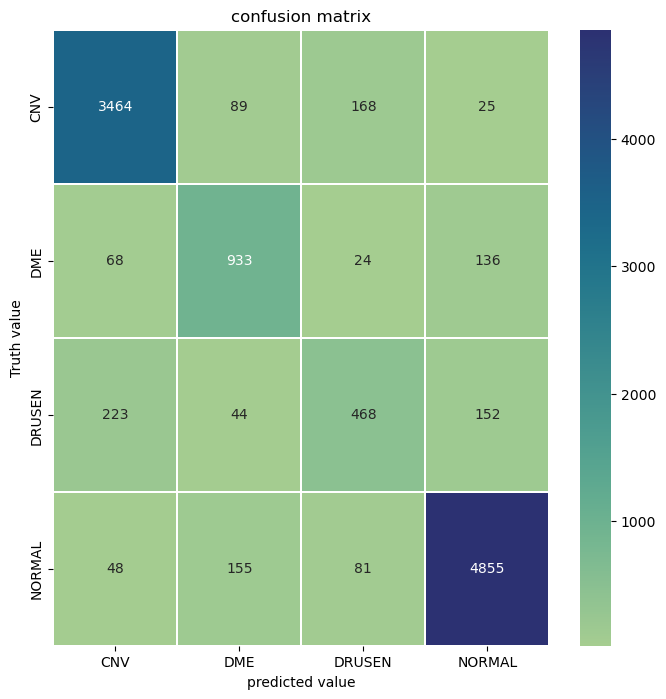

[[3464   89  168   25]
 [  68  933   24  136]
 [ 223   44  468  152]
 [  48  155   81 4855]]


In [49]:
X_Label = ['CNV','DME','DRUSEN','NORMAL']
Y_Label = ['CNV','DME','DRUSEN','NORMAL']

cm = sklearn.metrics.confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(8,8))
sns.heatmap(cm, fmt='.0f', cmap="crest", annot=True, linewidths=0.2, xticklabels=X_Label, yticklabels=Y_Label)
plt.title('confusion matrix')
plt.xlabel('predicted value')
plt.ylabel('Truth value')
plt.show()
print(sklearn.metrics.confusion_matrix(true_classes, predicted_classes))

In [50]:
print("Accuracy", sklearn.metrics.accuracy_score(true_classes, predicted_classes))

Accuracy 0.8890514954724229
